In [1]:
import pandas as pd
import math
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
def load_data():
    df_stock = pd.read_csv('./Data/Fama_French/stock_daily_data.csv')
    df_stock['date'] = pd.to_datetime(df_stock['date'])
    df_1a_sum = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_sum.csv')
    df_7_sum = pd.read_csv('./Data/Fama_French/risk_scores_item_7_sum.csv')
    df_score = pd.merge(df_1a_sum, df_7_sum,
                    on=['year', 'ticker'],
                    suffixes=('_1a', '_7'),
                    how='inner')
    df_score.dropna()
    return df_stock, df_score

In [3]:
df_stock = pd.read_csv('./Data/Fama_French/stock_daily_data.csv')
df_stock['date'] = pd.to_datetime(df_stock['date'])
df_1a_sum = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_sum.csv')
df_7_sum = pd.read_csv('./Data/Fama_French/risk_scores_item_7_sum.csv')
df_7_min = pd.read_csv('./Data/Fama_French/risk_scores_item_7_min.csv')
df_1a_min = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_min.csv')
df_score = pd.merge(df_1a_sum, df_7_sum,
                    on=['year', 'ticker'],
                    suffixes=('_1a', '_7'),
                    how='outer')



In [4]:
df_7_min.sort_values(by=['risk_score']).head(20)

,year,ticker,risk_score
765,2021,PG,-6
635,2022,MCO,-5
887,2020,TDY,-5
181,2020,CE,-5
60,2021,AMCR,-5
857,2022,SPG,-4
772,2020,PKG,-4
171,2021,CCI,-4
852,2022,SNA,-4
260,2021,CSGP,-4


<Axes: >

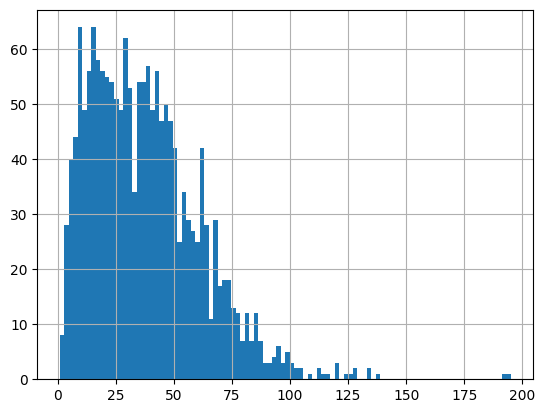

In [5]:
df_score['risk_score_1a'].hist(bins=100)

<Axes: >

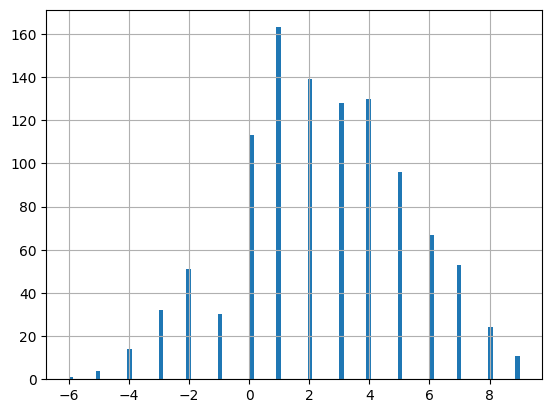

In [6]:
df_7_min['risk_score'].hist(bins=100)

<Axes: >

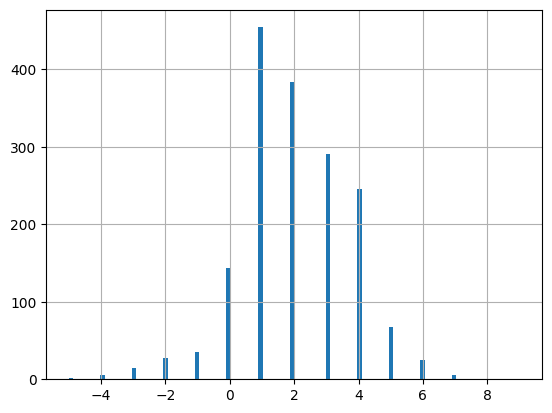

In [7]:
df_1a_min['risk_score'].hist(bins=100)

In [8]:
df_1a = pd.merge(df_1a_sum, df_1a_min,
         on=['year', 'ticker'],
         suffixes=('_1a', '_1a_min'),
            how='inner')

df_7 = pd.merge(df_7_sum, df_7_min,
         on=['year', 'ticker'],
         suffixes=('_7', '_7_min'),
            how='inner')

df_1a['has_reponse_1a'] = df_1a['risk_score_1a_min'] < -1
df_7['has_reponse_7'] = df_7['risk_score_7_min'] < 0

df_merged = pd.merge(df_1a, df_7,
         on=['year', 'ticker'],
         how='outer',)

df_merged['has_reponse'] = df_merged['has_reponse_1a'] | df_merged['has_reponse_7']

print('\nYear: 2020\n', df_merged[df_merged['year'] == 2020]['has_reponse'].value_counts())
print('\nYear: 2021\n', df_merged[df_merged['year'] == 2021]['has_reponse'].value_counts())
print('\nYear: 2022\n', df_merged[df_merged['year'] == 2022]['has_reponse'].value_counts())
print('\nYear: 2023\n', df_merged[df_merged['year'] == 2023]['has_reponse'].value_counts())


Year: 2020
 has_reponse
False    356
True      60
Name: count, dtype: int64

Year: 2021
 has_reponse
False    367
True      59
Name: count, dtype: int64

Year: 2022
 has_reponse
False    397
True      26
Name: count, dtype: int64

Year: 2023
 has_reponse
False    434
True      10
Name: count, dtype: int64


In [9]:
print('\nYear: 2020\n', df_merged[df_merged['year'] == 2020]['has_reponse_7'].value_counts())
print('\nYear: 2021\n', df_merged[df_merged['year'] == 2021]['has_reponse_7'].value_counts())
print('\nYear: 2022\n', df_merged[df_merged['year'] == 2022]['has_reponse_7'].value_counts())
print('\nYear: 2023\n', df_merged[df_merged['year'] == 2023]['has_reponse_7'].value_counts())


Year: 2020
 has_reponse_7
False    310
True      54
Name: count, dtype: int64

Year: 2021
 has_reponse_7
False    283
True      54
Name: count, dtype: int64

Year: 2022
 has_reponse_7
False    210
True      18
Name: count, dtype: int64

Year: 2023
 has_reponse_7
False    121
True       6
Name: count, dtype: int64


In [10]:
df_has_response = df_merged[df_merged['has_reponse']== True]

In [11]:
df_has_response['has_reponse_1a'].value_counts()

has_reponse_1a
False    104
True      51
Name: count, dtype: int64

In [12]:
df_has_response['has_reponse_7'].value_counts()

has_reponse_7
True     130
False     12
Name: count, dtype: int64

In [13]:
df_has_response[df_has_response['has_reponse_7']==False]

,year,ticker,risk_score_1a,risk_score_1a_min,has_reponse_1a,risk_score_7,risk_score_7_min,has_reponse_7,has_reponse
15,2020,AIZ,116.0,-2.0,True,6.0,6.0,False,True
18,2020,ALB,22.0,-2.0,True,24.0,1.0,False,True
189,2020,HUBB,35.0,-2.0,True,49.0,0.0,False,True
300,2020,PARA,65.0,-2.0,True,4.0,4.0,False,True
344,2020,SPGI,127.0,-3.0,True,4.0,4.0,False,True
488,2021,CF,25.0,-2.0,True,5.0,5.0,False,True
582,2021,GEN,44.0,-3.0,True,25.0,0.0,False,True
734,2021,POOL,49.0,-2.0,True,19.0,1.0,False,True
838,2021,YUM,56.0,-2.0,True,8.0,8.0,False,True
891,2022,BALL,12.0,-5.0,True,8.0,4.0,False,True


In [14]:
df_merged[(df_merged['has_reponse_1a']) & (df_merged['has_reponse_7'])]

,year,ticker,risk_score_1a,risk_score_1a_min,has_reponse_1a,risk_score_7,risk_score_7_min,has_reponse_7,has_reponse
66,2020,CCI,24.0,-3.0,True,-3.0,-3.0,True,True
110,2020,DG,43.0,-2.0,True,20.0,-2.0,True,True
121,2020,DRI,63.0,-3.0,True,33.0,-3.0,True,True
126,2020,EBAY,34.0,-3.0,True,7.0,-3.0,True,True
152,2020,FDS,28.0,-3.0,True,1.0,-3.0,True,True
282,2020,NOC,67.0,-4.0,True,7.0,-4.0,True,True
309,2020,PKG,27.0,-4.0,True,3.0,-4.0,True,True
316,2020,POOL,20.0,-2.0,True,25.0,-2.0,True,True
341,2020,SMCI,44.0,-2.0,True,17.0,-1.0,True,True
401,2020,WEC,36.0,-2.0,True,20.0,-2.0,True,True


In [ ]:
def construct_portfolio(df_stock, df_score, split_num=20, bool_print=True, action=0.25, no_action=0.75):

    rebalance_years = sorted(df_score['year'].unique())
    all_portfolio_returns = []
    for year in rebalance_years:
        df_year = df_score[df_score['year'] == year].copy()
        df_year_action = df_year[df_year['risk_score_7'] <= df_year['risk_score_7'].quantile(action)].sort_values(by='risk_score_1a', ascending=False)
        df_year_no_action = df_year[df_year['risk_score_7'] > df_year['risk_score_7'].quantile(no_action)].sort_values(by='risk_score_1a', ascending=False)


        min_split_number_action =  split_num if len(df_year_action) > 2 * split_num else math.floor(len(df_year_action) / 2)
        min_split_number_no_action = split_num if len(df_year_no_action) > 2 * split_num else math.floor(len(df_year_no_action) / 2)

        portfolio_action_high_risk = df_year_action[:min_split_number_action]['ticker'].tolist()
        portfolio_action_low_risk = df_year_action[-min_split_number_action:]['ticker'].tolist()
        portfolio_no_action_high_risk = df_year_no_action[:min_split_number_no_action]['ticker'].tolist()
        portfolio_no_action_low_risk = df_year_no_action[-min_split_number_no_action:]['ticker'].tolist()

        if bool_print:
            print("Year:", year)
            print("Shape of df_year_action:", df_year_action.shape)
            print("Shape of df_year_no_action:", df_year_no_action.shape)
            print("Min split number for action portfolio:", min_split_number_action)
            print("Min split number for no action portfolio:", min_split_number_no_action)
            print("Action Portfolio High Risk Tickers:", portfolio_action_high_risk)
            print("Action Portfolio Low Risk Tickers:", portfolio_action_low_risk)
            print("No Action Portfolio High Risk Tickers:", portfolio_no_action_high_risk)
            print("No Action Portfolio Low Risk Tickers:", portfolio_no_action_low_risk)

        holding_period_start = pd.to_datetime(f'{year+1}-07-01')
        holding_period_end = pd.to_datetime(f'{year+2}-06-30')

        period_data = df_stock[
            (df_stock['date'] >= holding_period_start) & 
            (df_stock['date'] <= holding_period_end)
        ]

        high_risk_action_score = period_data[period_data['ticker'].isin(portfolio_action_high_risk)].groupby('date')['return'].mean().to_list()
        low_risk_action_score = period_data[period_data['ticker'].isin(portfolio_action_low_risk)].groupby('date')['return'].mean().to_list()
        high_risk_no_action_score = period_data[period_data['ticker'].isin(portfolio_no_action_high_risk)].groupby('date')['return'].mean().to_list()
        low_risk_no_action_score = period_data[period_data['ticker'].isin(portfolio_no_action_low_risk)].groupby('date')['return'].mean().to_list()



        ls_return = 1.65 * np.array(high_risk_action_score) - np.array(high_risk_no_action_score)

        period_results = pd.DataFrame({
            'date': period_data['date'].unique(),
            'With Mitigation': high_risk_action_score,
            'low_risk_action': low_risk_action_score,
            'With No Mitigation': high_risk_no_action_score,
            # 'low_risk_no_action': low_risk_no_action_score,
            # 'LS': ls_return,
            'S&P 500': period_data.groupby('date')['return'].mean().to_list()
        })
        period_results.set_index('date', inplace=True)
        all_portfolio_returns.append(period_results)
    df_portfolio_returns = pd.concat(all_portfolio_returns)
    return df_portfolio_returns

# construct_portfolio(*load_data(), split_num=20, bool_print=True)

In [16]:
def analyze_and_visualize(portfolios, save_path='figure_1_cumulative_returns.png', end_date='2025-07-01'):
    trading_days = 252
    annual_return = portfolios.mean() * trading_days
    annual_volatility = portfolios.std() * np.sqrt(trading_days)
    sharpe_ratio = annual_return / annual_volatility # Simple Sharpe Ratio, assuming risk-free rate is 0
    
    # Calculate maximum drawdown
    cumulative_returns = (1 + portfolios).cumprod() -1
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    performance_summary = pd.DataFrame({
        'Annualized Return': [f"{x:.2%}" for x in annual_return],
        'Annualized Volatility': [f"{x:.2%}" for x in annual_volatility],
        'Sharpe Ratio': [f"{x:.2f}" for x in sharpe_ratio],
        'Max Drawdown': [f"{x:.2%}" for x in max_drawdown]
    }, index=portfolios.columns)
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))
    cumulative_returns = cumulative_returns[cumulative_returns.index <= end_date]
    print(performance_summary)

    color_list = ['#fb8500', '#219ebc', "#6D6D6D", '#8ac926', '#ffb703']
    line_style = 'solid'
    for col, color in zip(cumulative_returns.columns, color_list):
        if col == 'S&P 500':
            line_style = '--'
        ax.plot(cumulative_returns.index, cumulative_returns[col], label=col, color=color, alpha=1, linewidth=2, linestyle=line_style)
    # ax.set_title('Portfolio Cumulative Returns', fontsize=16)
    ax.set_ylabel('Cumulative Return', fontsize=25, fontweight='bold')
    ax.set_xlabel('Date', fontsize=25, fontweight='bold')
    # legend_list = ['With Mitigation','Without Mitigation', 'S&P 500']
    ax.legend(fontsize=25)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.xticks(rotation=45, fontsize=25)
    plt.yticks(fontsize=25)
    # plt.title('Portfolio Cumulative Returns, Action vs No Action (with baseline S&P 500)', fontsize=25)
    plt.tight_layout()
    plt.savefig('./Figs/portfolio_cumulative_returns_action_vs_no_action.pdf', dpi=600)

                   Annualized Return Annualized Volatility Sharpe Ratio  \
With Mitigation               13.91%                18.61%         0.75   
With No Mitigation             7.53%                17.45%         0.43   
S&P 500                       10.72%                17.38%         0.62   

                   Max Drawdown  
With Mitigation        -636.97%  
With No Mitigation     -206.86%  
S&P 500                -257.38%  


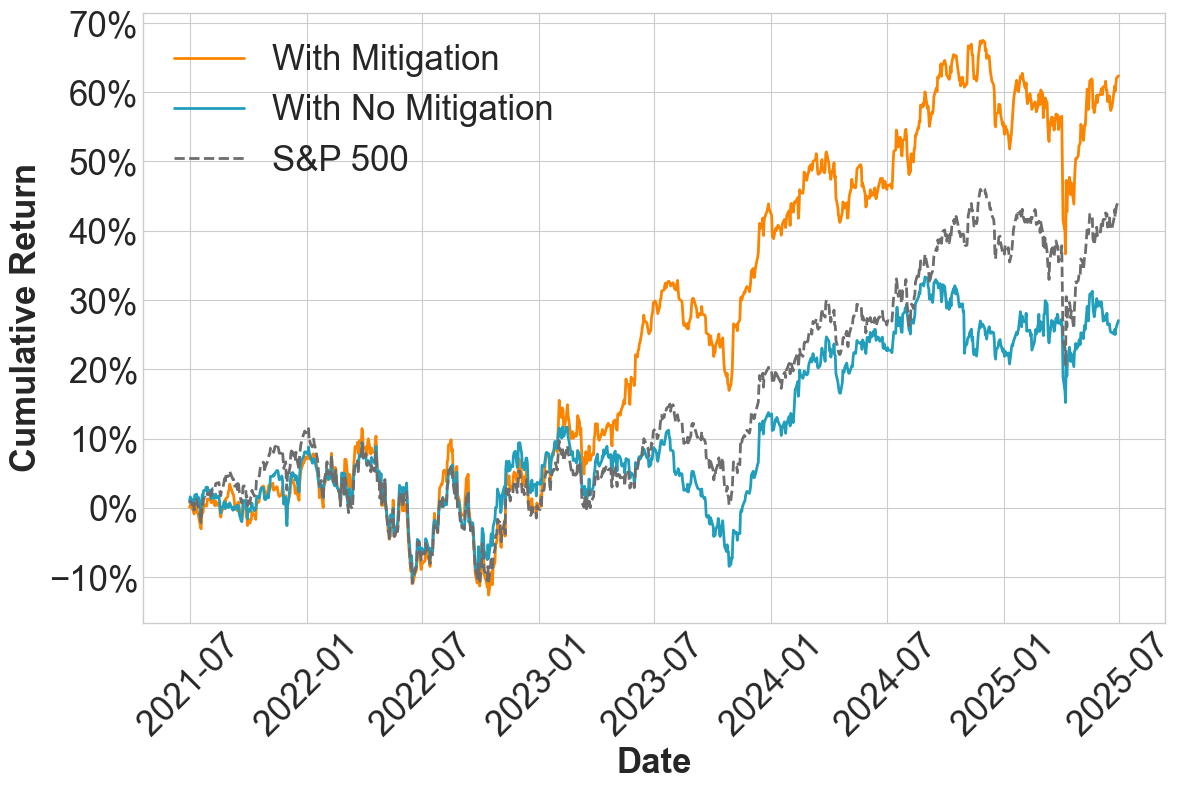

In [17]:
portfolios = construct_portfolio(*load_data(), split_num=20, bool_print=False, action=0.2, no_action=0.8)  # Adjust split_num as needed
analyze_and_visualize(portfolios, end_date='2028-07-05')

In [18]:
a_2021 = ['RSG', 'CAG', 'TMUS', 'INCY', 'PPG', 'KMB', 'ON', 'ALB', 'ED', 'CHRW', 'ABT', 'ROL', 'POOL', 'AWK', 'CB', 'AXON', 'CTAS', 'EW', 'AMZN', 'VRSK']
a_2022 = ['ERIE', 'CMCSA', 'CPAY', 'EL', 'FITB', 'SPG', 'TPL', 'MCK', 'JCI', 'VRSN', 'HSY', 'CHRW', 'CTAS', 'DAY', 'FFIV', 'CMI', 'AMZN', 'AWK', 'VRSK', 'CPRT']
a_2023 = ['AEE', 'RSG', 'BA', 'DAY', 'PRU', 'FSLR', 'KMB', 'ESS', 'HSY', 'CBRE', 'VMC', 'DRI', 'AZO', 'LHX', 'CMI', 'ROK', 'FFIV', 'VRSK', 'EL', 'HAL']
a_2024 = ['RSG', 'CAG', 'TMUS', 'INCY', 'PPG', 'KMB', 'ON', 'ALB', 'ED', 'CHRW', 'ABT', 'ROL', 'POOL', 'AWK', 'CB', 'AXON', 'CTAS', 'EW', 'AMZN', 'VRSK']
